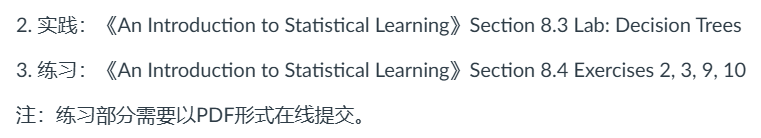

2,

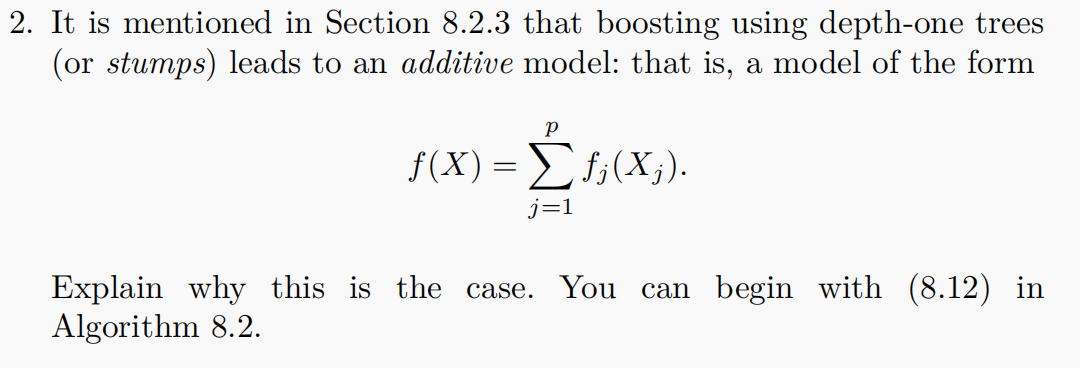

8.1中的的方程是：
$$
f(x) = \sum_{b=1}^B(\lambda \hat{f}^b(x)
$$

其中$\hat{f}^b(x)$代表第b树有1个划分，因为1-depth树只涉及1个变量，而$x$的总函数涉及将每个变量的结果相加，因此这个模型是一个加性模型，比如说2-depth树就允许两个变量之间的交互

3，

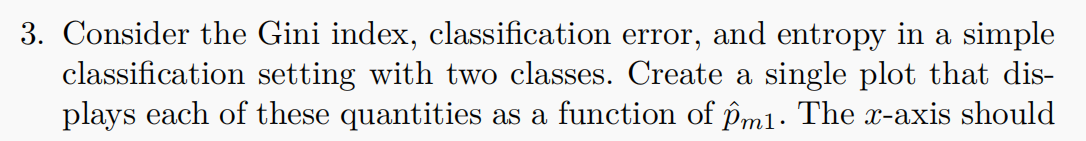

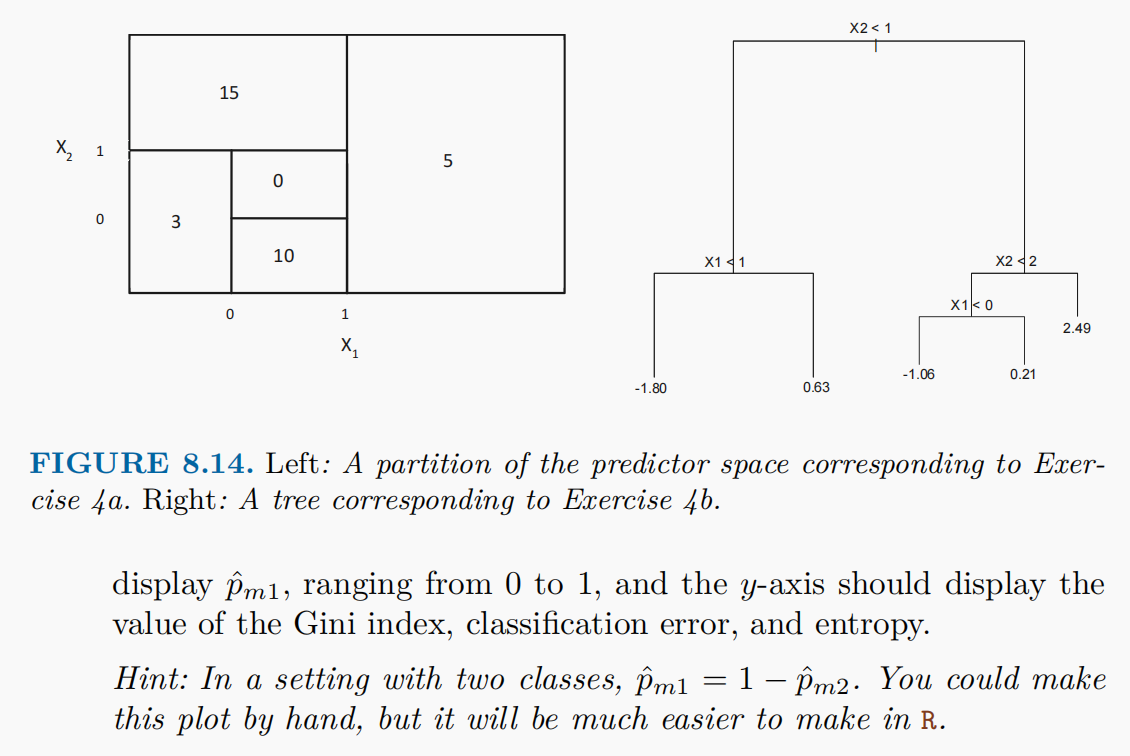

简单来说Gini index是：
$$G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$$

entropy熵是：
$$D = -\sum_{k=1}^{K} \hat{p}_{mk}\log(\hat{p}_{mk})$$

错分率是：
$$E = 1 - \max_k(\hat{p}_{mk})$$

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


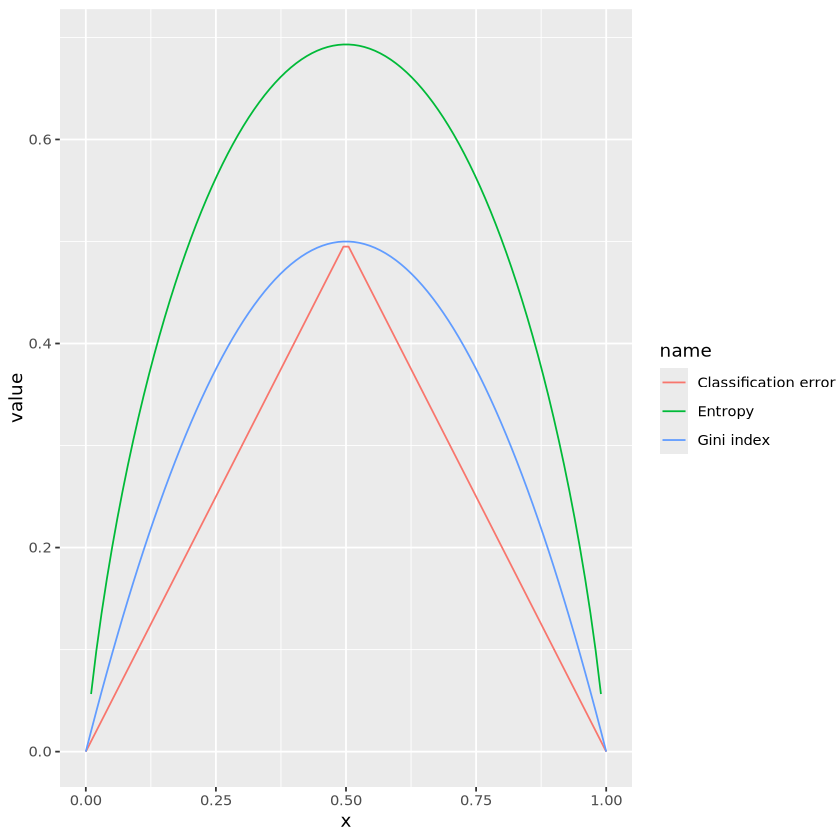

In [2]:
# 当只有两个类时
library(tidyverse)

p <- seq(0, 1, length.out = 100)
data.frame(
  x = p,
  "Gini index" = p * (1 - p) * 2,
  "Entropy" = -(p * log(p) + (1 - p) * log(1 - p)),
  "Classification error" = 1 - pmax(p, 1 - p),
  check.names = FALSE
) |>
  pivot_longer(!x) |>
  ggplot(aes(x = x, y = value, color = name)) +
  geom_line(na.rm = TRUE)

9，

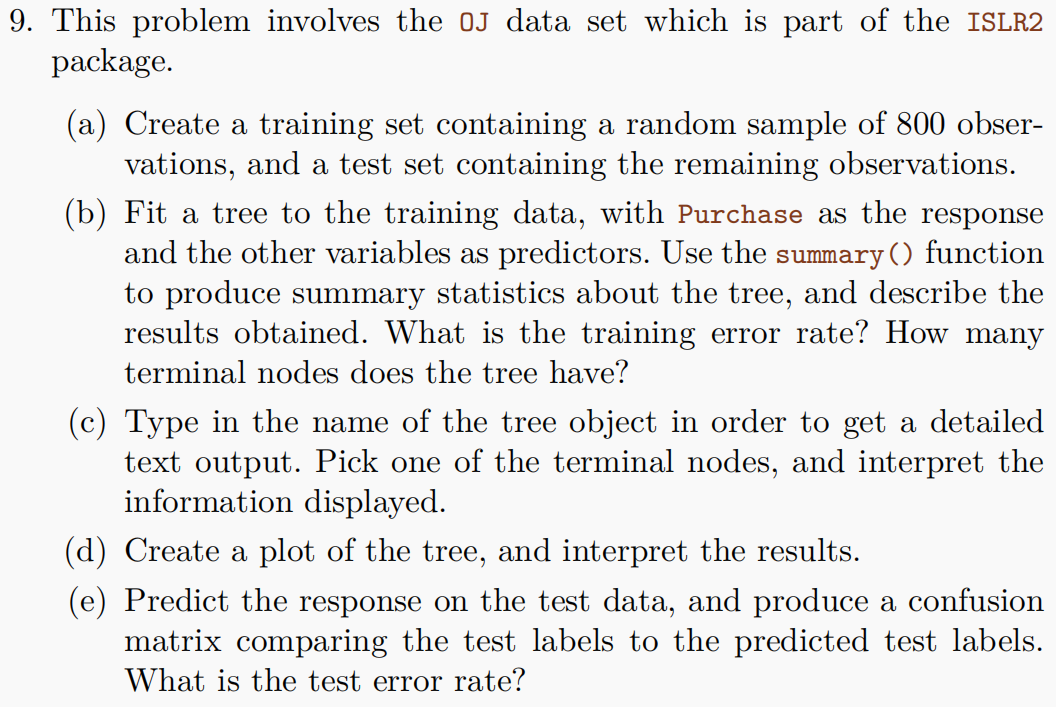

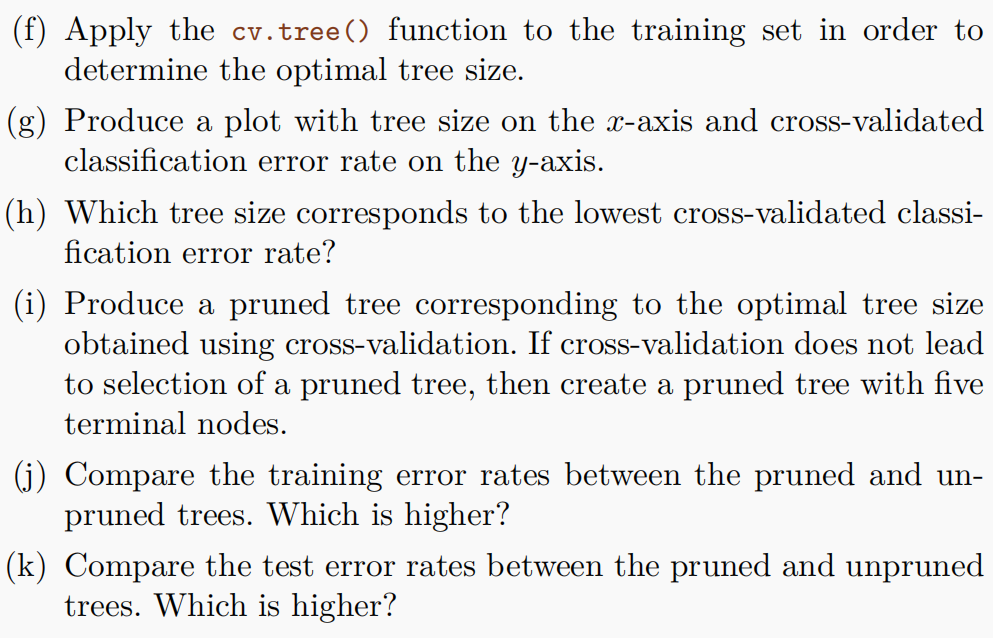

In [4]:
# a
library(ISLR2)
set.seed(2025)
train <- sample(1:nrow(OJ), 800)
test <- setdiff(1:nrow(OJ), train)

In [5]:
train
test

[1]  909  460  932  279  187  461  972  891  571  907  159  142  549  797  764
 [16]  857  630  686  940  371   59  144   49  399  626  185  433  964  536  986
 [31] 1065  539  214  850  593  440  432  772  336 1014  363   41  599   15  524
 [46]  725  387  300  264  648   23  776  898  482  154  781 1002  528  873  743
 [61] 1048  687 1005  708  654  827  878  652  340  608 1067  425  807  927  583
 [76]  564   37  228  468  846  754  904  117  937  254 1028  820  988  676  758
 [91]  586  992  164  510  672  531  170  825  218  981  691  824  882  639  791
[106]  148  590  405  865 1017  110  210   10  241  911   18  385  158  871  692
[121]  284  177  430  504  240    6   90  715  250  447  308   25  465  774  369
[136] 1035  121  256  314  295  953  301  503  922  331  429  580  557  500  182
[151]  671   53  306  644  894  748  438    5  316  397   28  297 1024  163  568
[166]  840 1069  396  152  280  320  750  828  943  427  298  414   81  713    8
[181]  416  474  388  607  278  428  348  130  872  799  382  206  559  979  680
[196]  408  643  699  730  184  656  551  147  864  679  808  835  222  209  145
[211]  499   58  572  285  819  977  966  976  831  362  186  533  268  444  251
[226]  612  407  169  576  619  107   40   98  452  199  383  451   16  847 1015
[241]  333  415  577  683  337  629 1013  944  919  867  198  749  516  345  995
[256]  768  269   71  203    2  855   73  682  717  450  765  719  211  633  982
[271]  655  155  223  573  116  261  554  965  274 1059  334  156  562  803  233
[286]  622  281  135 1066  104  711  812  616  646 1026  225  696  522 1044  782
[301]  631 1050   44 1029  707   94  861  621  126  745  585  378  906  569  305
[316]   26  417 1049  710  903   32  726  120  594  789 1061  201 1057  473  197
[331]  322  512   99  479  896  398  207  661  380  851  923  886  834  195 1033
[346]  969   96  555  464  176   47  517  434  941   11  665  127 1022  403  171
[361]  702  263  160  420  277   13  217  868  879  553  734  119  784  560  601
[376]  818   33  620  360  520  877  598   87  139  404  384  231  335  905  196
[391]  332  476  361   62   68   31  166  973  822  852  950  821  874  413  975
[406]  544  118  938  190 1055  307  265  947  605  610  704   55  290  641  368
[421]  786  563  647   38 1036  341   52  122   84  674   20  456  449  143 1009
[436]  890  153  435 1034  756  845  304   76  741  752  393  732    1  595  321
[451]  506  193  722  140 1043 1052  483  365  423  260  215  869 1058  437 1039
[466]  785  662  315  860  454  634  939 1062 1041  136  446   45  729  352  747
[481] 1051  490   34   72  993  179  735  817  740  491  346  668  463  980  566
[496]  606  401  895  175  324  310  685  226  678  167 1053  112  439  234  395
[511]  431  809  489  736  892  411  359   83  232  418  561  137  350  105  826
[526]  832  720  660  194  912  983  239  727  959  902  309  102  866   30  875
[541]  168 1004   54  174  497  667  364  830 1010  762  547  924  445  259  436
[556] 1025  589  513  917  128  534  266 1021  205  123  967  757  132   22   14
[571]  737  565  292  829   27  108  984  901  556  246  889 1030  493  753  470
[586]  375  353   65  659  673  801 1064  541   56  787  442  958  579  106  494
[601]  509  376   19  191 1006  230   85  502  248  928   36  342  779  237 1063
[616]  443  357  766  664  486 1019  521  858  574  204  299  929  161  948  970
[631]  567  180   29  997  588 1012  578   82  519  815  615  893  462 1020  448
[646]  529  495  954  181   88   35  617   78  582  763  255  525  165  424  581
[661]  111  471  688  848  354   89   12  881   60  329  636  343  651  777   57
[676]  669  303  526  192 1011  597 1037  355 1054  709  373   70  410  374  999
[691]  897  330  356  916  325  488  632  900   64  930  326  915  149  409  618
[706]  844  276  946  994  134  400  484  426  317  926  100  990  507   46  814
[721]  609 1056  538  477  613  837  813  996  790   95  985  138  548  146   43
[736]  480  637  515  611  712  7

[1]    3    4    7    9   17   21   24   39   42   48   50   51   61   63   66
 [16]   67   69   74   79   80   86   92   93   97  109  113  114  115  124  125
 [31]  129  131  133  141  151  162  172  173  178  183  189  200  208  212  216
 [46]  219  221  227  229  235  236  238  242  243  244  247  249  252  253  257
 [61]  262  271  272  273  282  286  293  294  296  311  313  319  323  328  338
 [76]  339  344  347  349  351  358  366  370  372  377  379  381  386  389  390
 [91]  391  392  402  406  419  421  441  453  455  457  458  459  467  469  472
[106]  475  478  481  485  487  492  496  498  501  505  508  511  514  518  523
[121]  527  530  537  540  542  543  545  546  550  552  558  570  575  584  587
[136]  591  596  600  602  603  604  614  624  625  627  628  635  638  640  649
[151]  650  653  657  663  666  670  675  677  684  689  690  694  695  698  700
[166]  701  703  718  721  723  724  728  731  738  739  742  744  751  755  759
[181]  760  769  770  771  773  775  778  780  783  788  792  793  794  795  796
[196]  798  804  805  806  810  811  816  823  833  836  838  839  841  842  849
[211]  853  854  856  859  862  870  876  880  883  885  887  888  899  908  910
[226]  913  914  918  920  921  925  931  933  935  942  945  949  951  952  955
[241]  956  957  960  961  962  968  971  974  987  989  991  998 1000 1001 1003
[256] 1007 1008 1016 1018 1027 1031 1032 1038 1040 1042 1045 1046 1047 1068 1070

In [8]:
install.packages("tree")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [9]:
# b

library(tree)

tr <- tree(Purchase ~ ., data = OJ[train, ])
summary(tr) 


Classification tree:
tree(formula = Purchase ~ ., data = OJ[train, ])
Variables actually used in tree construction:
[1] "LoyalCH"       "PriceDiff"     "PriceMM"       "ListPriceDiff"
[5] "PctDiscMM"    
Number of terminal nodes:  8 
Residual mean deviance:  0.7291 = 577.4 / 792 
Misclassification error rate: 0.1688 = 135 / 800 

In [10]:
# c

tr

node), split, n, deviance, yval, (yprob)
      * denotes terminal node

 1) root 800 1062.000 CH ( 0.62125 0.37875 )  
   2) LoyalCH < 0.48285 296  328.400 MM ( 0.24324 0.75676 )  
     4) LoyalCH < 0.136698 94   33.080 MM ( 0.04255 0.95745 ) *
     5) LoyalCH > 0.136698 202  258.100 MM ( 0.33663 0.66337 )  
      10) PriceDiff < 0.05 88   80.360 MM ( 0.17045 0.82955 )  
        20) PriceMM < 2.11 63   69.160 MM ( 0.23810 0.76190 ) *
        21) PriceMM > 2.11 25    0.000 MM ( 0.00000 1.00000 ) *
      11) PriceDiff > 0.05 114  157.500 MM ( 0.46491 0.53509 ) *
   3) LoyalCH > 0.48285 504  437.700 CH ( 0.84325 0.15675 )  
     6) LoyalCH < 0.764572 243  288.100 CH ( 0.72016 0.27984 )  
      12) ListPriceDiff < 0.235 96  133.000 MM ( 0.48958 0.51042 )  
        24) PctDiscMM < 0.196196 78  105.600 CH ( 0.58974 0.41026 ) *
        25) PctDiscMM > 0.196196 18    7.724 MM ( 0.05556 0.94444 ) *
      13) ListPriceDiff > 0.235 147  113.200 CH ( 0.87075 0.12925 ) *
     7) LoyalCH > 0.764572 

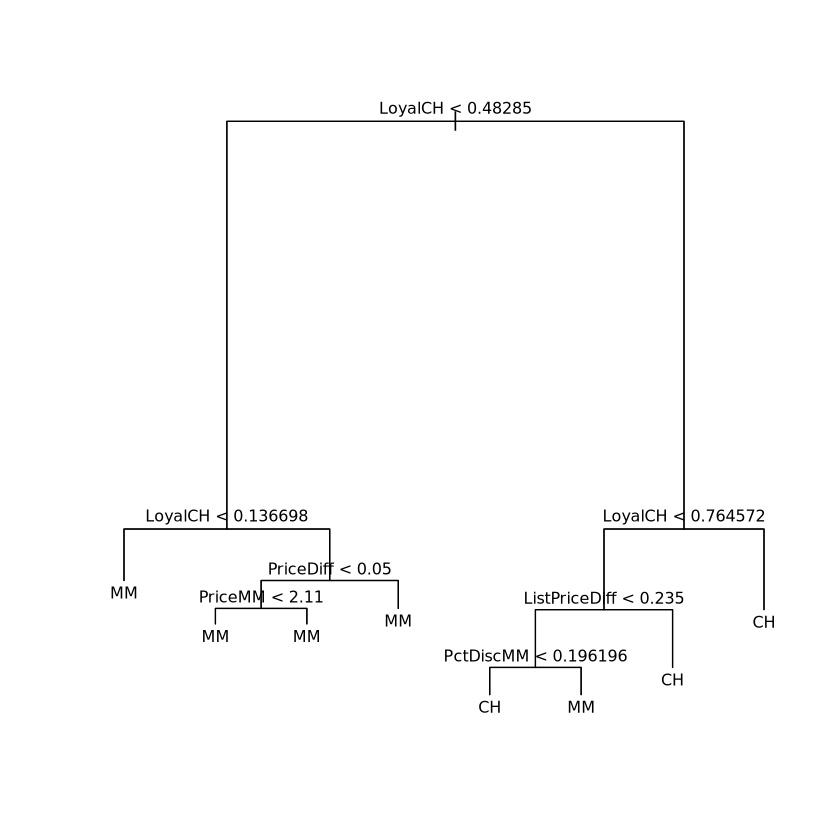

In [11]:
# d

plot(tr)
text(tr, pretty = 0, digits = 2, cex = 0.8)

In [12]:
# e

table(predict(tr, OJ[test, ], type = "class"), OJ[test, "Purchase"])

    
      CH  MM
  CH 132  26
  MM  24  88

In [13]:
# f

set.seed(2025)
res <- cv.tree(tr)

In [14]:
res

$size
[1] 8 7 6 5 4 3 2 1

$dev
[1]  680.1988  688.0523  720.2812  720.6543  742.8509  736.7547  772.3555
[8] 1064.2409

$k
[1]      -Inf  11.20452  19.71399  20.22765  37.28609  41.87838  58.41310
[8] 295.37443

$method
[1] "deviance"

attr(,"class")
[1] "prune"         "tree.sequence"

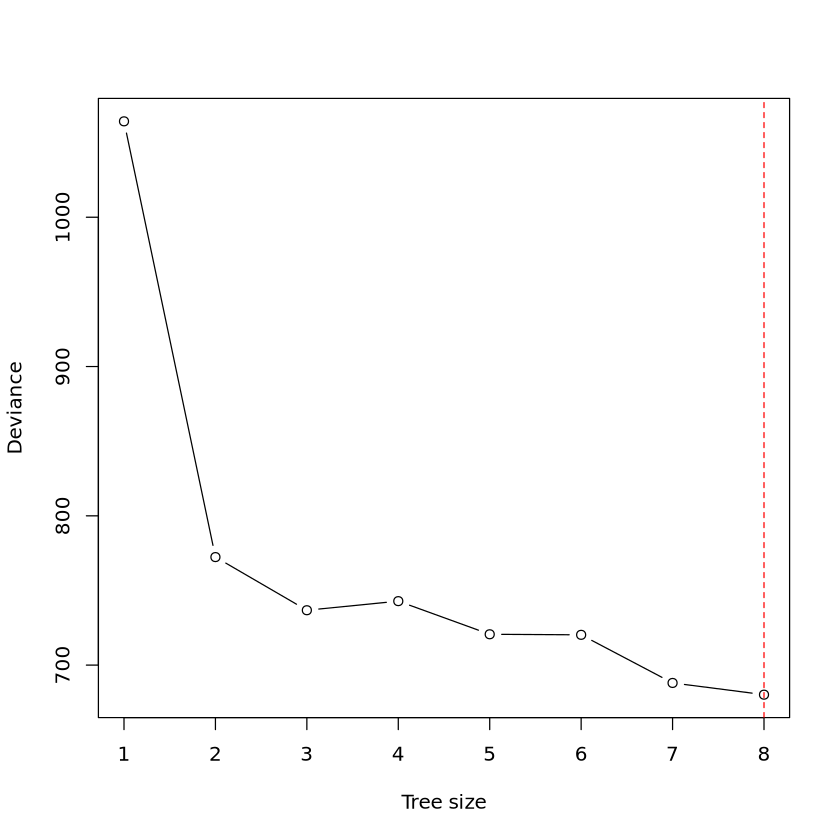

In [15]:
# g

plot(res$size, res$dev, type = "b", xlab = "Tree size", ylab = "Deviance")
min <- which.min(res$dev)
abline(v = res$size[min], lty = 2, col = "red")


In [16]:
# h

res$size[min]

[1] 8

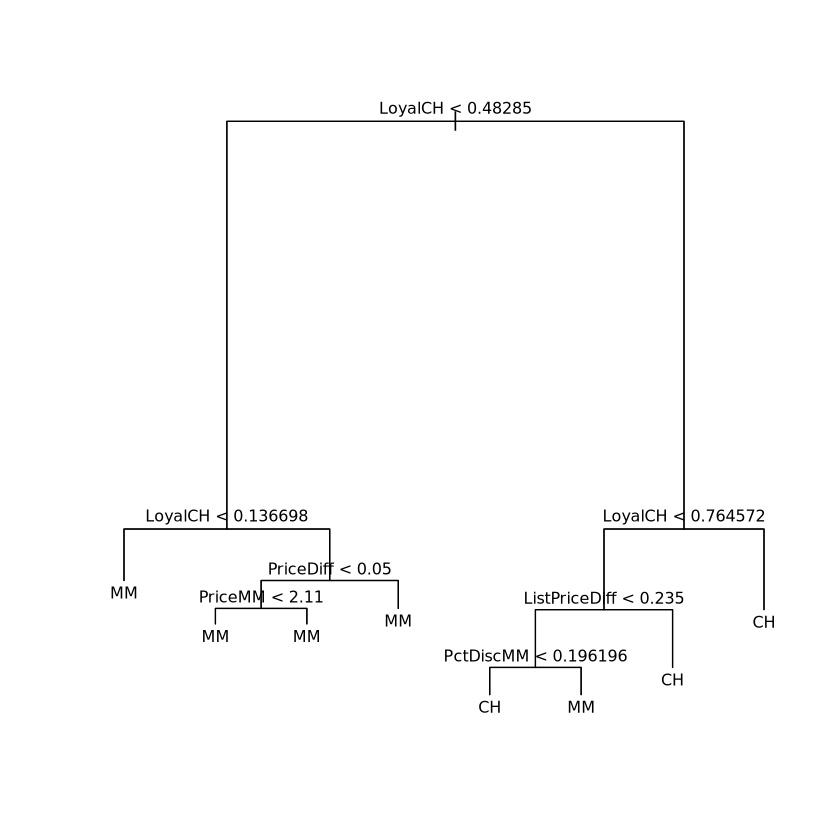

In [17]:
# i

ptr <- prune.tree(tr, best = res$size[min])
plot(ptr)
text(ptr, pretty = 0, digits = 2, cex = 0.8)

In [ ]:
# j

oj_misclass <- function(model) {
  summary(model)$misclass[1] / summary(model)$misclass[2]
}
oj_misclass(tr)
oj_misclass(ptr)

# 分不出来

[1] 0.16875

[1] 0.16875

In [ ]:
# k

oj_err <- function(model) {
  p <- predict(model, newdata = OJ[test, ], type = "class")
  mean(p != OJ[test, "Purchase"])
}
oj_err(tr)
oj_err(ptr)

# 暂时也分不出来

[1] 0.1851852

[1] 0.1851852

10，

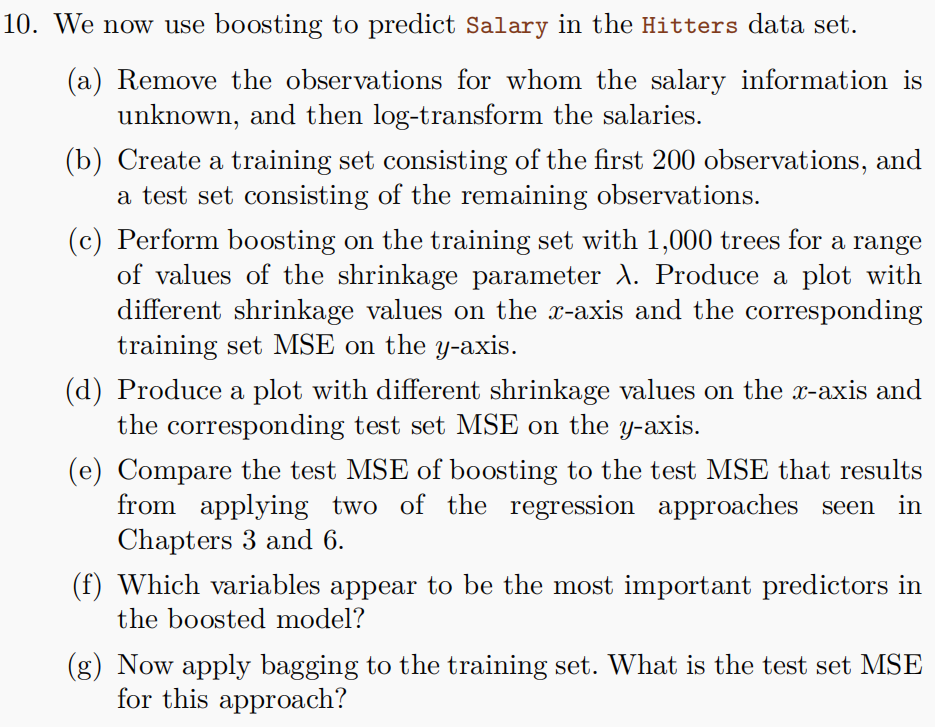

In [20]:
# a

dat <- Hitters
dat <- dat[!is.na(dat$Salary), ]
dat$Salary <- log(dat$Salary)
dat

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<dbl>,<fct>
-Alan Ashby,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,6.163315,N
-Alvin Davis,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,6.173786,A
-Andre Dawson,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,6.214608,N
-Andres Galarraga,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,4.516339,N
-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,6.620073,A
-Al Newman,185,37,1,23,8,21,2,214,42,1,30,9,24,N,E,76,127,7,4.248495,A
-Argenis Salazar,298,73,0,24,24,7,3,509,108,0,41,37,12,A,W,121,283,9,4.605170,A
-Andres Thomas,323,81,6,26,32,8,2,341,86,6,32,34,8,N,W,143,290,19,4.317488,N
-Andre Thornton,401,92,17,49,66,65,13,5206,1332,253,784,890,866,A,E,0,0,0,7.003065,A


In [21]:
# b

train <- 1:200
test <- setdiff(1:nrow(dat), train)

In [23]:
install.packages("gbm")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



Loaded gbm 2.2.2

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3



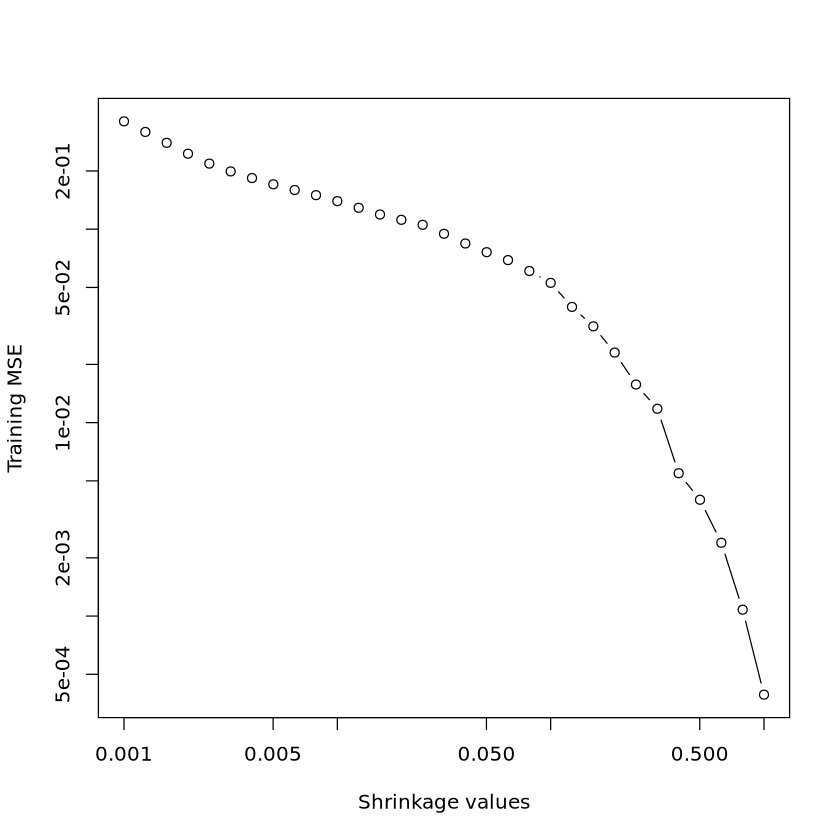

In [24]:
# c

library(gbm)
set.seed(2025)
lambdas <- 10^seq(-3, 0, by = 0.1)
fits <- lapply(lambdas, function(lam) {
  gbm(Salary ~ .,
    data = dat[train, ], distribution = "gaussian",
    n.trees = 1000, shrinkage = lam
  )
})
errs <- sapply(fits, function(fit) {
  p <- predict(fit, dat[train, ], n.trees = 1000)
  mean((p - dat[train, ]$Salary)^2)
})
plot(lambdas, errs,
  type = "b", xlab = "Shrinkage values",
  ylab = "Training MSE", log = "xy"
)

[1] 0.2584966

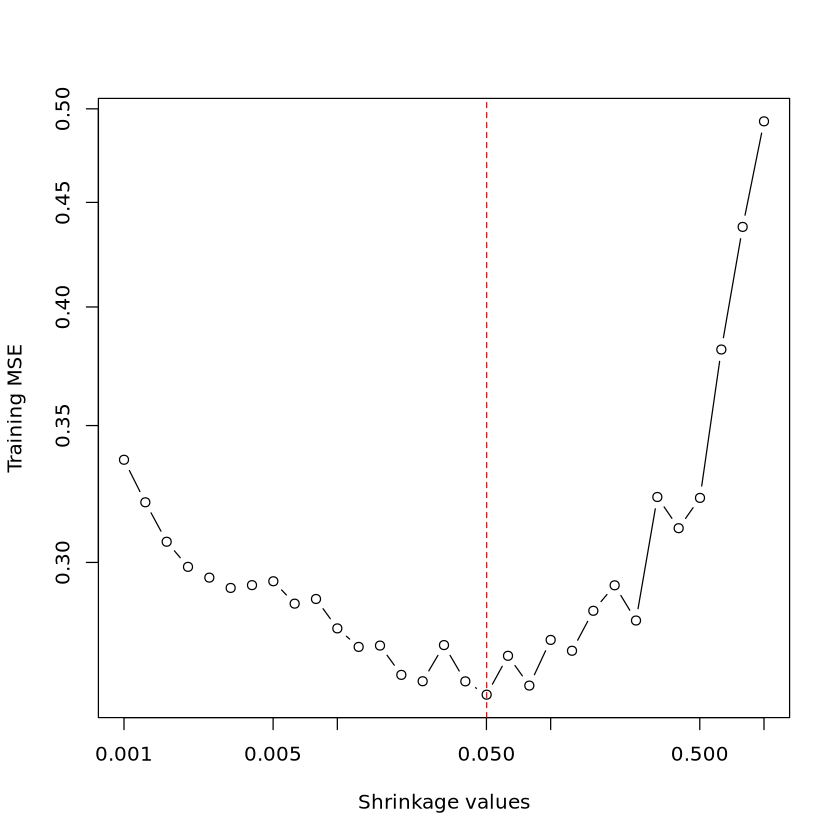

In [ ]:
# d

errs <- sapply(fits, function(fit) {
  p <- predict(fit, dat[test, ], n.trees = 1000)
  mean((p - dat[test, ]$Salary)^2)
})
plot(lambdas, errs,
  type = "b", xlab = "Shrinkage values",
  ylab = "Training MSE", log = "xy"
)
min(errs) 
abline(v = lambdas[which.min(errs)], lty = 2, col = "red")

In [26]:
# e

# 线性回归
fit1 <- lm(Salary ~ ., data = dat[train, ])
mean((predict(fit1, dat[test, ]) - dat[test, "Salary"])^2)

# 岭回归
library(glmnet)
x <- model.matrix(Salary ~ ., data = dat[train, ])
x.test <- model.matrix(Salary ~ ., data = dat[test, ])
y <- dat[train, "Salary"]
fit2 <- glmnet(x, y, alpha = 1)
mean((predict(fit2, s = 0.1, newx = x.test) - dat[test, "Salary"])^2)

[1] 0.4917959

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8



[1] 0.4389054

,var,rel.inf
,<chr>,<dbl>
CAtBat,CAtBat,17.1748006
CHits,CHits,13.8017685
CRBI,CRBI,9.4348044
PutOuts,PutOuts,6.5575761
Walks,Walks,6.0509734
Years,Years,6.0440502
CRuns,CRuns,5.7359341
CWalks,CWalks,5.5726482
CHmRun,CHmRun,4.9867757


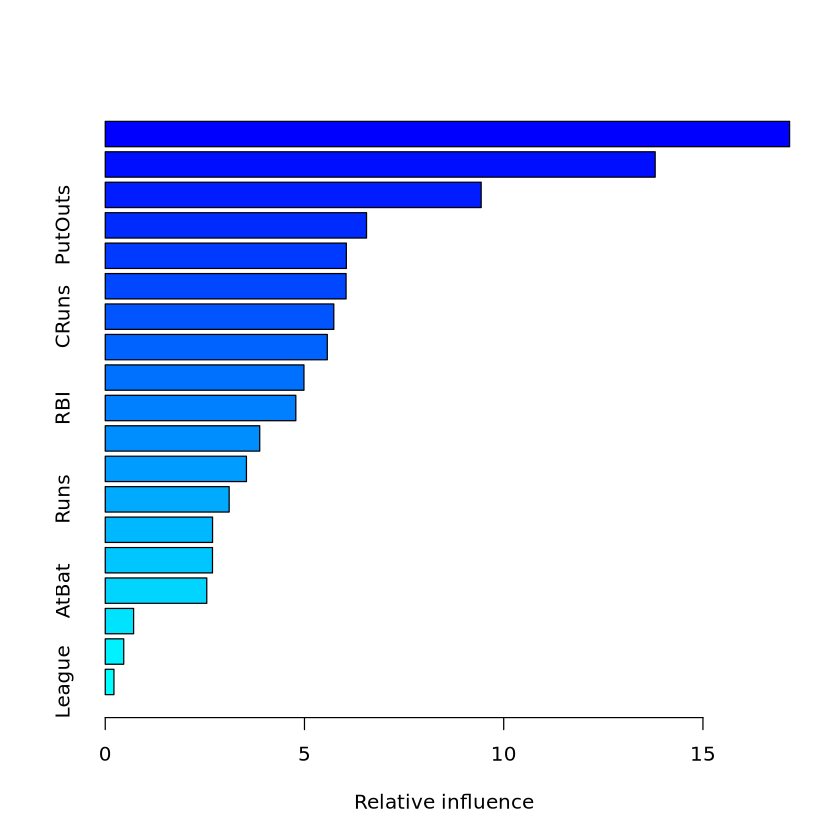

In [27]:
# f

summary(fits[[which.min(errs)]])

In [31]:
install.packages("randomForest")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [32]:
# g

library("randomForest")
set.seed(2025)
bagged <- randomForest(Salary ~ ., data = dat[train, ], mtry = 19, ntree = 1000)
mean((predict(bagged, newdata = dat[test, ]) - dat[test, "Salary"])^2)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




[1] 0.231634